In [1]:
import pandas as pd

# Path to the CSV file in the ESC-50 dataset
Path = '/Users/bchhaglani/Desktop/Audio_privacy/ESC-50-master/'
csv_path = Path + 'meta/esc50.csv'

# Load the CSV into a DataFrame
df = pd.read_csv(csv_path)
audio_path_prefix = Path+'/audio/'


df = df[['filename', 'category']]

print(df.head())


            filename        category
0   1-100032-A-0.wav             dog
1  1-100038-A-14.wav  chirping_birds
2  1-100210-A-36.wav  vacuum_cleaner
3  1-100210-B-36.wav  vacuum_cleaner
4  1-101296-A-19.wav    thunderstorm


In [2]:
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [3]:
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset metadata
csv_path = Path+'/meta/esc50.csv'
df = pd.read_csv(csv_path)


import librosa
import numpy as np

def extract_audio_features2(y, sr):
    
    features = {}
    
    # Time-domain features
    signal_energy = np.sum(y ** 2)
    zero_crossing_rate = np.mean(librosa.feature.zero_crossing_rate(y)[0])
    rms_energy = np.mean(librosa.feature.rms(y=y)[0])
    
    features['Signal Energy'] = signal_energy
    features['Zero Crossing Rate'] = zero_crossing_rate
    features['RMS Energy'] = rms_energy
    
    # Frequency-domain features
    spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)[0])
    spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)[0])
    spectral_contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))
    spectral_flatness = np.mean(librosa.feature.spectral_flatness(y=y))
    mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr), axis=1)
    y_harmonic, y_percussive = librosa.effects.hpss(y)
    hnr = np.var(y_harmonic) / np.var(y_percussive)
    
    features['Spectral Centroid'] = spectral_centroid
    features['Spectral Bandwidth'] = spectral_bandwidth
    features['Spectral Contrast'] = spectral_contrast
    features['Spectral Flatness'] = spectral_flatness
    features['MFCCs'] = mfccs
    features['HNR'] = hnr
    
    return features


# import librosa
# import numpy as np

def extract_audio_features(y, sr):
    # Load the audio file
    
    # Initialize the features list
    features = []
    
    # Time Domain Features
#     duration = librosa.get_duration(y=y, sr=sr)
#     features.append(("Duration", duration))
    amplitude = np.mean(np.abs(y))
    features.append(amplitude)
    zero_crossing_rate = np.mean(librosa.feature.zero_crossing_rate(y=y)[0])
    features.append( zero_crossing_rate)
    rms_energy = np.mean(librosa.feature.rms(y=y)[0])
    features.append( rms_energy)

    
    # Frequency Domain Features
    spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)[0])
    features.append(spectral_centroid)
    spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)[0])
    features.append(spectral_bandwidth)
    spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)[0])
    features.append( spectral_rolloff)
    spectral_flatness = np.mean(librosa.feature.spectral_flatness(y=y)[0])
    features.append(spectral_flatness)
    spectral_contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))
    features.append(spectral_contrast)

#     # Rhythm Features
#     tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
#     features.append( tempo)
    
#     # MFCCs
#     mfccs = librosa.feature.mfcc(y=y, sr=sr)
#     for idx, mfcc in enumerate(mfccs):
#         features.append( np.mean(mfcc))
        
    y_harmonic, y_percussive = librosa.effects.hpss(y)
    hnr = np.var(y_harmonic) / np.var(y_percussive)
    features.append( np.mean(hnr))
    return features



# # Example usage
# audio_file_path = 'path/to/your/audio/file.wav'
# features = extract_audio_features(audio_file_path)

# # To print extracted features
# for feature_name, feature_value in features.items():
#     print(f"{feature_name}: {feature_value}")



# Function to split audio into overlapping windows
def split_audio(y, window_length, hop_length):
    num_samples = len(y)
    start_sample = 0
    while start_sample + window_length < num_samples:
        yield y[start_sample:start_sample+window_length]
        start_sample += hop_length
        
        
        
        
def extract_features_from_file(file_path):
    y, sr = librosa.load(file_path, sr=None)
    y, index = librosa.effects.trim(y, top_db=20)
    window_length = int(sr * 0.5)  # 500 ms window
    hop_length = int(sr * 0.1)    # 20% stride (100 ms)
    features = []
    for segment in split_audio(y, window_length, hop_length):
        feat = extract_audio_features(segment, sr)
#         print(feat)
        features.append(feat)
    return features


# # Extract features for each audio file
audio_path_prefix = Path+'/audio/'
features_list = []
labels_list = []
for _, row in df.iterrows():
    features = extract_features_from_file(audio_path_prefix + row['filename'])
    features_list.extend(features)
    labels_list.extend([row['target']] * len(features))
    print(len(features_list))



0
45
90
135
180
215
237
239
284
290
294
339
383
428
428
473
518
538
541
545
545
589
634
678
723
768
813
852
897
941
984
1003
1024
1069
1114
1159
1204
1249
1287
1320
1360
1400
1444
1484
1521
1558
1595
1622
1662
1671
1671
1716
1744
1746
1789
1834
1879
1924
1969
2014
2059
2093
2138
2183
2217
2260
2305
2350
2365
2410
2452
2484
2529
2574
2619
2664
2706


/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_2955/3891457460.py:90: RuntimeWarning: invalid value encountered in float_scalars
  hnr = np.var(y_harmonic) / np.var(y_percussive)


2744
2785
2830
2875
2920
2964
2966
2969
2969
2970
3015
3060
3105
3150
3195
3238
3282
3327
3345
3377
3405
3450
3495
3535
3580
3625
3670
3705
3750
3793
3838
3883
3928
3972
4016
4016
4034
4075
4120
4165
4201
4243
4288
4331
4376
4421
4466
4511
4556
4594
4614
4640
4685
4711
4744
4777
4822
4864
4909
4910
4917
4931
4973
5018
5031
5076
5121
5133
5138
5154
5199
5244
5289
5334
5379
5424
5424
5469
5496
5527
5552
5592
5637
5681
5726
5736
5781
5826
5871
5916
5916
5959
6004
6034
6079
6124
6168
6201
6237
6282
6294
6307
6341
6386
6430
6475
6520
6561
6562
6579
6583
6589
6634
6637
6681
6698
6739
6775
6820
6865
6882
6927
6972
7012
7033
7050
7052
7097
7142
7164
7209
7209
7254
7299
7344
7389
7403
7448
7480
7525
7570
7613
7654
7699
7744
7777
7822
7867
7885
7889
7934
7979
8021
8065
8110
8155
8200
8243
8262
8307
8352
8397
8420
8445
8479
8501
8546
8579
8624
8669
8714
8746
8790
8821
8864
8903
8944
8979
9010
9052
9097
9141
9186
9222
9232
9255
9298
9343
9374
9401
9446
9491
9536
9581
9582
9627
9662
9707
9752
9797


In [4]:
# for i in features_list:
#     print(len(i))

In [5]:

X = np.array(features_list)
# X = np.reshape(X, [X.shape[0],49])
y = np.array(labels_list)

# X_ = X[:,:-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
X_train.shape

(57282, 9)

In [7]:
np.any(np.isnan(X_test))


True

In [8]:



X_test = X_test.astype(np.float)
X_train = X_train.astype(np.float)

X_test = np.nan_to_num(X_test)
X_train = np.nan_to_num(X_train)

/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_2955/1462255237.py:1: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  X_test = X_test.astype(np.float)
/var/folders/qf/r_bx8wf14lx6m_jgptyp_vmr0000gq/T/ipykernel_2955/1462255237.py:2: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  X_train = X_train.astype(np.float)


In [13]:
# Train a RandomForest classifier
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

# Predict on test data
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 83.42%


In [14]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)



In [15]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.77      0.61      0.68       234\n           1       0.87      0.77      0.81       132\n           2       0.72      0.70      0.71       317\n           3       0.76      0.69      0.73       270\n           4       0.87      0.89      0.88       350\n           5       0.79      0.64      0.70       266\n           6       0.68      0.63      0.66       304\n           7       0.82      0.91      0.87       286\n           8       0.76      0.72      0.74       323\n           9       0.81      0.86      0.83       297\n          10       0.90      0.99      0.95       351\n          11       0.84      0.94      0.88       357\n          12       0.85      0.95      0.90       329\n          13       0.97      0.99      0.98       346\n          14       0.86      0.87      0.87       301\n          15       0.79      0.78      0.78       240\n          16       0.89      0.96      0.92       370\n       

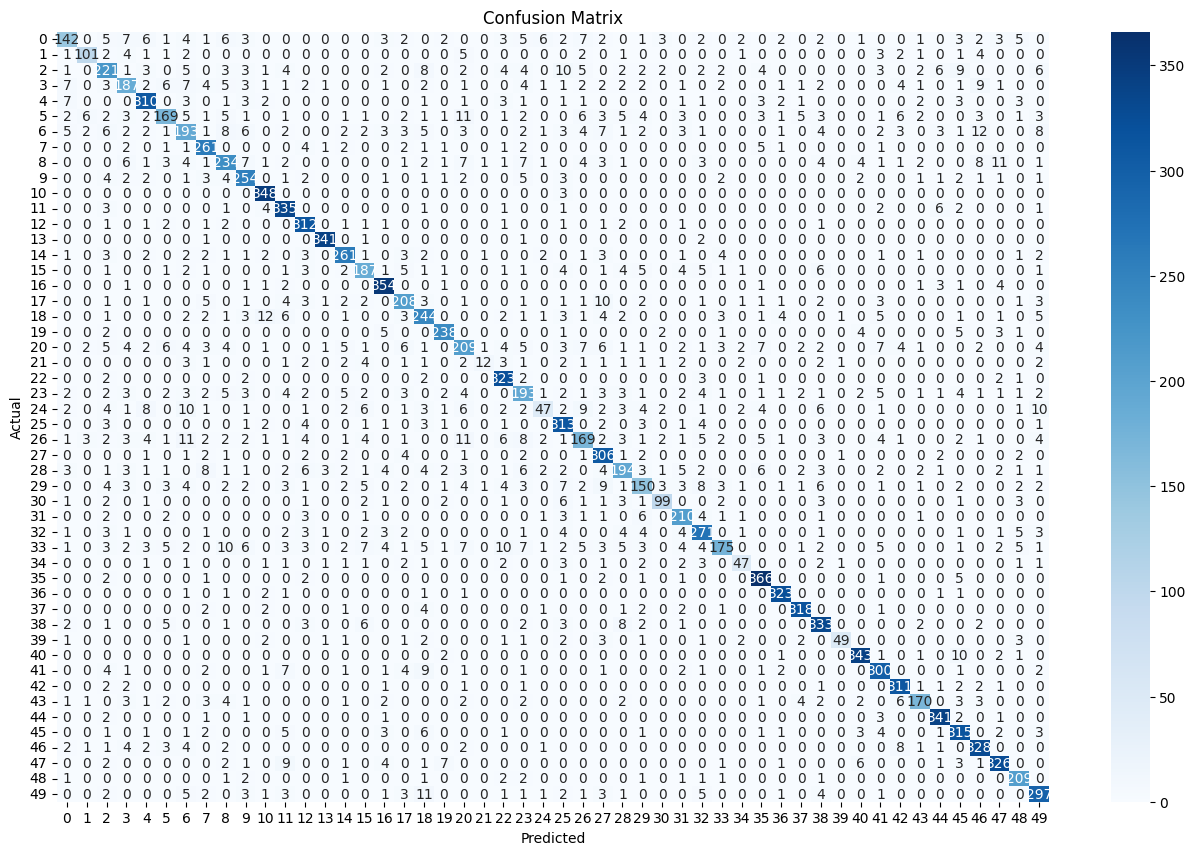

In [16]:
classes = np.unique(y_test)

import matplotlib.pyplot as plt
import seaborn as sns
# Plot confusion matrix using a heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

precision: [0.77173913 0.87068966 0.72459016 0.76326531 0.86592179 0.78604651
 0.68439716 0.82334385 0.76221498 0.81410256 0.9038961  0.83541147
 0.85245902 0.97150997 0.86423841 0.78571429 0.89168766 0.8
 0.74617737 0.89811321 0.728223   0.75       0.85       0.69927536
 0.68115942 0.79846939 0.72844828 0.79274611 0.77290837 0.72115385
 0.86086957 0.81712062 0.80895522 0.85365854 0.74603175 0.89051095
 0.93623188 0.9380531  0.83879093 0.9245283  0.9346049  0.83798883
 0.89884393 0.87179487 0.92411924 0.82460733 0.86543536 0.8956044
 0.84615385 0.81593407]
recall: [0.60683761 0.76515152 0.69716088 0.69259259 0.88571429 0.63533835
 0.63486842 0.91258741 0.7244582  0.85521886 0.99145299 0.93837535
 0.94832827 0.98554913 0.86710963 0.77916667 0.95675676 0.8
 0.78709677 0.90839695 0.65517241 0.24489796 0.9556213  0.6942446
 0.32413793 0.91788856 0.6101083  0.9244713  0.67832168 0.60728745
 0.75572519 0.88235294 0.84952978 0.58139535 0.62666667 0.95811518
 0.97289157 0.94925373 0.89757412 0

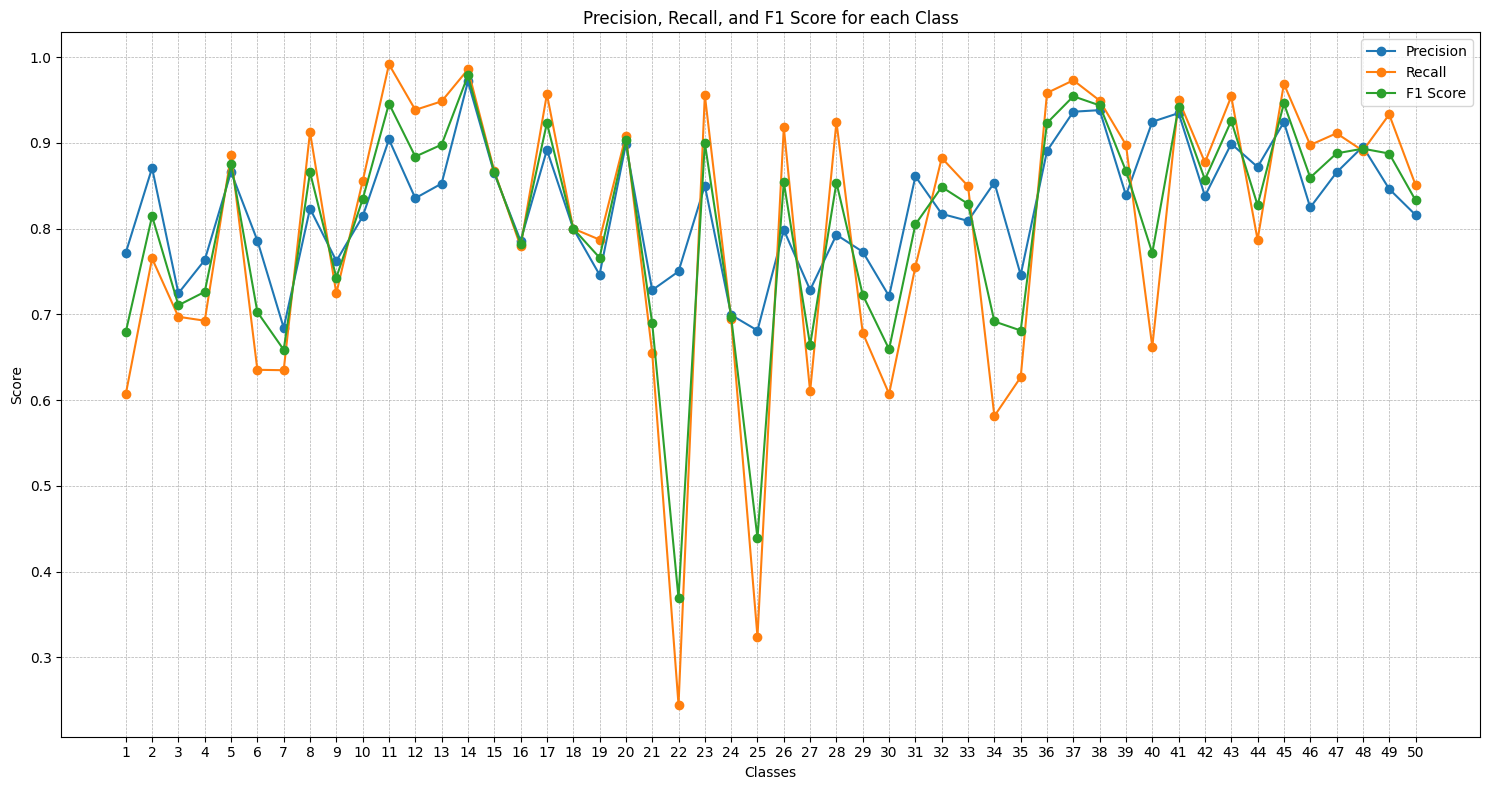

In [17]:
from sklearn.metrics import precision_recall_fscore_support as score
precision, recall, fscore, support = score(y_test, y_pred)

print('precision: {}'.format(precision))
print('recall: {}'.format(recall))
print('fscore: {}'.format(fscore))
print('support: {}'.format(support))

import matplotlib.pyplot as plt

# The data you provided
classes = list(range(1, 51))
# precision = [
#     0.9147286821705426, 0.984375, 0.9496644295302014, 0.9932203389830508, 1.0, 
#     # ... add all other precision values here
#     0.9501915708812261, 0.9921259842519685
# ]
# recall = [
#     0.9833333333333333, 0.9767441860465116, 0.9691780821917808, 0.9865319865319865, 1.0,
#     # ... add all other recall values here
#     0.9802371541501976, 0.9921259842519685
# ]
# f1 = [
#     0.9477911646586346, 0.980544747081712, 0.9593220338983051, 0.9898648648648648, 1.0,
#     # ... add all other F1 values here
#     0.9649805447470816, 0.9921259842519685
# ]

# Plotting
plt.figure(figsize=(15, 8))
plt.plot(classes, precision, marker='o', label='Precision')
plt.plot(classes, recall, marker='o', label='Recall')
plt.plot(classes, fscore, marker='o', label='F1 Score')
plt.xlabel('Classes')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score for each Class')
plt.xticks(classes)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [97]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="frame will be truncated. Increase NFFT to avoid.")

import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
import pandas as pd
import math
import os
import python_speech_features as speech_feat
import glob
import wave
from numpy.fft import fft, ifft, fft2, ifft2, fftshift
from sklearn import preprocessing
from scipy.signal import butter, lfilter, filtfilt, freqz
from dtaidistance import dtw
import pickle
from scipy import signal

# from project_strings import *
# import audio_processing as ap
# import opensmile

# template_R_X_a = pd.read_csv('templates/budsLive-focused-new/template_R_X_a_f_hfp.csv', header=None)[0]
# template_R_Y_a = pd.read_csv('templates/budsLive-focused-new/template_R_Y_a_f_hfp.csv', header=None)[0]
# template_R_Z_a = pd.read_csv('templates/budsLive-focused-new/template_R_Z_a_f_hfp.csv', header=None)[0]
# template_L_X_a = pd.read_csv('templates/budsLive-focused-new/template_L_X_a_f_hfp.csv', header=None)[0]
# template_L_Y_a = pd.read_csv('templates/budsLive-focused-new/template_L_Y_a_f_hfp.csv', header=None)[0]
# template_L_Z_a = pd.read_csv('templates/budsLive-focused-new/template_L_Z_a_f_hfp.csv', header=None)[0]

class Device_Features:
    def __init__(self, slice, sampling_rate, magnitudes, freqs):
        self.data = slice
        self.sr = sampling_rate
        self.magnitudes =  magnitudes
        self.freqs = freqs

    def zcr(self):
        ans = 0
        signalDuration = float(len(self.data)) / float(self.sr)
        for i in range(1, len(self.data)):
            if self.data[i] * self.data[i - 1] < 0:
                ans += 1
        ans /= signalDuration
        return ans

    def SPlevel(self):
        data = self.data
        energy = 0
        for value in data:
            energy = energy + (float(value)*float(value))
        power = 20 * math.log10((math.sqrt(energy)+0.0001) / float(len(data)))
        return power

    def Spec_Cent(self):
        magnitudes = self.magnitudes
        freqs = self.freqs
        return np.sum(magnitudes * freqs) / np.sum(magnitudes)

    def Spec_Spread(self):
        magnitudes = self.magnitudes
        freqs = self.freqs
        SC = self.Spec_Cent()
        M2 = np.sum(magnitudes * (freqs**2)) / np.sum(magnitudes)
        if np.sum(magnitudes) == 0:
            return 0
        else:
            return math.sqrt(M2 - SC**2)

    def Spec_Rolloff(self):
        magnitudes = self.magnitudes
        sr = self.sr
        spectralSum = 0
        for i in magnitudes:
            spectralSum += i
        rolloffSum = 0
        rolloffIndex = 0
        for index, value in enumerate(magnitudes):
            rolloffSum += value
            if rolloffSum > 0.85*spectralSum:
                rolloffIndex = index
                break
        return rolloffIndex*((sr/2.0)/len(magnitudes))

    def Spec_Flatness(self):
        magnitudes = self.magnitudes
        sr = self.sr
        num = 0
        den = 0

        for i in magnitudes:
            if i != 0:
                num += math.log(i)
                den += i
        if den != 0:
            return math.exp(num/float(len(magnitudes)))/(den/float(len(magnitudes)))
        else:
            return math.exp(1/float(len(magnitudes)))/(1/float(len(magnitudes)))

    def Quartile_Range(self):
        data = self.data
        data = np.abs(data)

        return np.quantile(data, 0.75) - np.quantile(data, 0.25)

    def Chroma(self):
        data = self.data
        magnitudes = self.magnitudes
        sr = self.sr

        # # implementing through PyAudio
        # nFFT = int(len(data))  # half of window_size
        # nChroma, nFreqsPerChroma = audioFeatureExtraction.stChromaFeaturesInit(nFFT, sr)
        # chroma_feat = audioFeatureExtraction.stChromaFeatures(data, sr, nChroma, nFreqsPerChroma)

        # copying the java library
        chroma = np.zeros(12)
        from audiolazy.lazy_midi import freq2midi
        df = (sr/2.0)/len(magnitudes)
        for index, value in enumerate(magnitudes):
            frequencyi = df*index
            if frequencyi == 0:
                pitch = 0
            else:
                pitch = freq2midi(frequencyi)

            pitchClass = int(pitch%12)
            if pitchClass < 0:
                pitchClass += 12
            chroma[pitchClass] += value

        maxElement = np.max(chroma)
        for index, value in enumerate(chroma):
            chroma[index] = value/maxElement
        return chroma.tolist()

    def Energy(self):
        data = self.data

        energy = 0
        for i in data:
            energy += i*i
        return energy/float(len(data))

def cough_post_processing(test_file_features, save_cough_snippets = False, audio_path = None, jump_size = 0.1):

    predictions = test_file_features['prediction'].tolist()

    # step 0, check the weak cough test
    for index, value in enumerate(predictions):
        if predictions[index] == 'cough':
            if test_file_features.iloc[index]['SPlevel'] < -77:
                predictions[index] = 'non-cough'
            elif test_file_features.iloc[index]['std'] < 0.011:
                predictions[index] = 'non-cough'
            elif test_file_features.iloc[index]['mfcc_00_std'] < 0.51:
                predictions[index] = 'non-cough'


    # step 1: converting a non-cough that is surrounded by cough predictions
    for index, value in enumerate(predictions[:-2]):
        if predictions[index] == 'cough' and predictions[index+2] == 'cough':
            predictions[index+1] = 'cough'

    # step 2:
    cough_like_numbers = 0
    cough_start_index, cough_stop_index = 0, 0
    found_a_cough = False
    post_predictions = [0] * len(predictions)
    for index, value in enumerate(predictions):
        if index in [0, 1, 2]:
            continue
        else:
            if predictions[index] == "cough":
                if found_a_cough:
                    index += 1
                    continue
                elif predictions[index - 1] == "cough" and predictions[index - 2] == "cough":
                    # you might need to add the next line if the jump size is smaller than 0.1
                    # and predictions[index - 2] == "cough" and predictions[index - 3] == "cough":
                    found_a_cough = True
                    cough_like_numbers += 1
                    cough_start_index = index - 2
                    index += 1
            else:
                if found_a_cough:
                    found_a_cough = False
                    cough_stop_index = index
                    post_predictions[cough_start_index:cough_stop_index] = [1] * (cough_stop_index - cough_start_index)
                    if save_cough_snippets:
                        sr_test, wav_test = sp.io.wavfile.read(audio_path)
                        audio_folder = '/'.join(audio_path.split('/')[:-1])
                        create_path(audio_folder+'/snippets')
                        sp.io.wavfile.write(audio_folder+'/snippets/' + audio_path.split('/')[-1][:-4] + "_cough_" +
                                            str(jump_size * (cough_start_index-2)) + '.wav', sr_test,
                                            wav_test[int(jump_size * sr_test * (cough_start_index-2)):int(
                                                jump_size * sr_test * (cough_stop_index+2))])
                else:
                    continue
    return post_predictions

def cross_correlation_using_fft(x, y):
    f1 = fft(x)
    f2 = fft(np.flipud(y))
    cc = np.real(ifft(f1 * f2))
    return fftshift(cc)

# shift < 0 means that y starts 'shift' time steps before x # shift &gt; 0 means that y starts 'shift' time steps after x
def compute_shift(x, y):
    assert len(x) == len(y)
    c = cross_correlation_using_fft(x, y)
    assert len(c) == len(x)
    zero_index = int(len(x) / 2) - 1
    shift = zero_index - np.argmax(c)
    return shift

def label_file_to_DF(txt_address):
    with open(txt_address) as f:
        start_time = []
        stop_time = []
        label = []
        for line in f:
            splitted = line.split()
            if splitted[2] == 'Start':
                start_time.append('%.4f'%float(splitted[0]))
            elif splitted[2] == 'End':
                stop_time.append('%.4f'%float(splitted[0]))
                label.append('cough')
            else:
                start_time.append('%.4f'%float(splitted[0]))
                stop_time.append('%.4f'%float(splitted[1]))
                label.append(splitted[2])

    label_DF = pd.DataFrame(data= {'start_times': start_time, 'stop_times': stop_time, 'label': label})
    return label_DF


def wave_file_to_device_feature_table_sliding(wav_path, win_size, jump_size, normalization =  False, label = None, downsampling_freq = None, hard_max = None):
    # creating features from field data
    sr, wav = sp.io.wavfile.read(wav_path)
    ####################################
    # picking the channel with higher amplitude if there is two channels
    try:
        if np.sum(np.absolute(np.array(wav[:, 0]))) > np.sum(np.absolute(np.array(wav[:, 1]))):
            wav = np.array(wav[:, 0])
            print("channel one")
        else:
            wav = np.array(wav[:, 1])
            print("channel two")
    except:
        print("single channel file")


    # expanding the resolution to float so it doesn't go out of range if wav is 16 bit int
    wav = wav.astype(int)

    # downsampling the file
    if downsampling_freq != None:
        downsampling_ratio = int(sr / downsampling_freq)
        wav = sp.signal.decimate(wav, downsampling_ratio)
        sr = downsampling_freq

    # normalizing the amplitude
    if normalization:
        if hard_max == None:
            max_val = max(wav)
            min_val = min(wav)
        else:
            max_val = max(max(wav), hard_max)
            min_val = max(min(wav), hard_max*-1)
        max_min_max = max(abs(max_val), abs(min_val))
        normalization_ratio = max_min_max * 2
        wav = (wav + max_min_max) / normalization_ratio - 0.5
    else:
        normalization_ratio = 1

    # rounding the digits after decimal point to a certain number
    wav = np.round(wav, decimals=5)
    #####################################
    feature_table = pd.DataFrame()
    for i in range(0, int((len(wav)) / (sr * jump_size))):
        if int(i * sr * jump_size + sr * win_size) > len(wav):
            break
        else:
            wave_piece = wav[int(i * sr * jump_size):int(i * sr * jump_size + sr * win_size)]
            feature_row_per_sub = wave_slice_to_device_features(wave_piece, sr)
            if feature_table.empty:
                feature_table = feature_row_per_sub
            else:
                feature_table = pd.concat([feature_table, feature_row_per_sub], axis=0)
    if normalization:
        feature_table['normalization_ratio'] = normalization_ratio

    if label != None:
        feature_table['label'] = label

    return feature_table

def normalize_DF(df):
    x = df.values  # returns a numpy array
    columns = df.columns.tolist()
    min_max_scaler = preprocessing.MinMaxScaler()
    x_scaled = min_max_scaler.fit_transform(x)
    df = pd.DataFrame(x_scaled, columns= columns)
    return df

def IMU_DTW_test(IMU_DF):
    template_R_X_a = pickle.load(open('templates/manual/template_R_X_a_f', 'rb'))
    template_R_Y_a = pickle.load(open('templates/manual/template_R_Y_a_f', 'rb'))
    template_R_Z_a = pickle.load(open('templates/manual/template_R_Z_a_f', 'rb'))
    template_L_X_a = pickle.load(open('templates/manual/template_L_X_a_f', 'rb'))
    template_L_Y_a = pickle.load(open('templates/manual/template_L_Y_a_f', 'rb'))
    template_L_Z_a = pickle.load(open('templates/manual/template_L_Z_a_f', 'rb'))

    jump_size = 10
    win_size = 50
    distance_list = []
    IMU_DF = IMU_DF[[' L_ACC_X_f', ' L_ACC_Y_f', ' L_ACC_Z_f', ' R_ACC_X_f', ' R_ACC_Y_f', ' R_ACC_Z_f']]
    for i in range(0, int(IMU_DF.shape[0] / jump_size)):
        if int(i * jump_size + win_size) > IMU_DF.shape[0]:
            break
        else:
            IMU_piece = IMU_DF.iloc[int(i * jump_size):int(i * jump_size + win_size)]
            alignment_R_X_a = dtw.distance(IMU_piece[' R_ACC_X_f'].tolist(), template_R_X_a.tolist())
            alignment_R_Y_a = dtw.distance(IMU_piece[' R_ACC_Y_f'].tolist(), template_R_Y_a.tolist())
            alignment_R_Z_a = dtw.distance(IMU_piece[' R_ACC_Z_f'].tolist(), template_R_Z_a.tolist())
            alignment_L_X_a = dtw.distance(IMU_piece[' L_ACC_X_f'].tolist(), template_L_X_a.tolist())
            alignment_L_Y_a = dtw.distance(IMU_piece[' L_ACC_Y_f'].tolist(), template_L_Y_a.tolist())
            alignment_L_Z_a = dtw.distance(IMU_piece[' L_ACC_Z_f'].tolist(), template_L_Z_a.tolist())
            distance_list.append((alignment_R_X_a * alignment_R_Y_a * alignment_R_Z_a * alignment_L_X_a * alignment_L_Y_a * alignment_L_Z_a)
                                 ** (1 / float(6)))

    plt.figure(figsize=(15, 5))
    plt.plot(distance_list)
    # plt.ylim([0, 5000])
    plt.savefig('distance.png')

    return distance_list

def process_the_chunk(top_index, chunk_size, wav_chunk, sr, IMU_chunk, enable_IMU, residual_wav, residual_IMU,
                      model, win_size, jump_size, post_processing, feature_list, silent_threshold, IMU_template_df):



    prediction_list = []
    distance_list = []
    wav_chunk = np.concatenate((residual_wav, wav_chunk), axis=None)
    IMU_chunk = pd.concat([residual_IMU, IMU_chunk])


    # looping through the chunk for prediction
    for i in range(0, int((len(wav_chunk)) / (sr * jump_size))):
        if int(i * sr * jump_size + sr * win_size) > len(wav_chunk):
            wave_piece = wav_chunk[int(i * sr * jump_size):]
            # IMU_piece = IMU_chunk.iloc[int(i * 80 * jump_size + 80 * win_size):]
        else:
            wave_piece = wav_chunk[int(i * sr * jump_size):int(i * sr * jump_size + sr * win_size)]

        feature_row_per_sub = wave_slice_to_device_features(wave_piece, sr)
        if feature_row_per_sub['SPlevel'][0] < silent_threshold:
            prediction_list.append(0)
            distance_list.append(10000)
        else:
            selected_features = feature_row_per_sub[feature_list]
            prediction = model.predict(selected_features)[0]

            if prediction == 'cough':
                prediction_list.append(2)
                if enable_IMU:
                    j = 0
                    distance = 10000
                    while j* jump_size * 50 + 20 < len(IMU_chunk):
                        IMU_piece = IMU_chunk.iloc[int(j* jump_size * 50):int(j* jump_size * 50 + 20)]
                        alignment_L_X_a = dtw.distance(IMU_piece['ACC_X_f'].tolist(), IMU_template_df['acc_x'].tolist())
                        alignment_L_Y_a = dtw.distance(IMU_piece['ACC_Y_f'].tolist(), IMU_template_df['acc_y'].tolist())
                        alignment_L_Z_a = dtw.distance(IMU_piece['ACC_Z_f'].tolist(), IMU_template_df['acc_z'].tolist())
                        distance = min(distance, (alignment_L_X_a * alignment_L_Y_a * alignment_L_Z_a) ** (1 / float(3)))
                        j += 1
                    distance_list.append(distance)
            else:
                prediction_list.append(1)
                distance_list.append(10000)

    final_cough_results = pd.DataFrame(columns=['start_time', 'end_time', 'duration', 'intensity', 'type'])
    if post_processing:
        index = 0
        cough_start_list = []
        cough_end_list = []
        post_prediction_list = prediction_list.copy()
        while index < (len(prediction_list[:-3])):
            if prediction_list[index] == 2 and prediction_list[index + 3] == 2:
                post_prediction_list[index + 1] = 2
                post_prediction_list[index + 2] = 2
                index += 4
            else:
                index += 1

        index = 0
        cough_happening = False
        while index < (len(post_prediction_list)):
            if post_prediction_list[index] == 2 and not cough_happening:
                if index == (len(post_prediction_list) -1):
                    cough_start_list.append(index)
                    cough_end_list.append(index+1)
                    break
                else:
                    cough_happening = True
                    cough_start_list.append(index)
                    index += 1
                    continue
            elif cough_happening and post_prediction_list[index] != 2:
                cough_happening = False
                cough_end_list.append(index)
                index += 1
                continue
            elif cough_happening and index == (len(post_prediction_list)-1):
                cough_end_list.append(index+1)
                break
            else:
                index += 1

        index = 0
        while index < len(cough_start_list):
            cough_duration = win_size + (cough_end_list[index] - cough_start_list[index] -1)* jump_size
            if cough_duration <= 0.5:
                post_prediction_list[cough_start_list[index]:cough_end_list[index]] = [0]*(cough_end_list[index] - cough_start_list[index])
                del cough_start_list[index]
                del cough_end_list[index]
            else:
                index += 1


        if enable_IMU:
            post_prediction_list_IMU = post_prediction_list.copy()
            for index, value in enumerate(cough_start_list):
                if min(distance_list[cough_start_list[index]:cough_end_list[index]]) > 4500:
                    post_prediction_list_IMU[cough_start_list[index]:cough_end_list[index]] = [1] * (cough_end_list[index] - cough_start_list[index])
                else:
                    cough_piece = wav_chunk[int((cough_start_list[index] + 1) * sr * jump_size):int(
                        (cough_end_list[index] - 1) * sr * jump_size + sr * win_size)]
                    cough_duration = win_size + (cough_end_list[index] - cough_start_list[index] - 1) * jump_size
                    cough_intensity = 20 * math.log10(np.sum(np.power(cough_piece * 2, 2))) / cough_duration
                    cough_start_time = chunk_size * top_index + (cough_start_list[index] + 1) * jump_size
                    cough_end_time = chunk_size * top_index + (cough_end_list[index] - 1) * jump_size + win_size
                    cough_results_this = pd.DataFrame(
                        {'start_time': [cough_start_time],
                         'end_time': [cough_end_time],
                         'duration': [cough_end_time - cough_start_time],
                         'intensity': [cough_intensity],
                         'type': ['dry']})
                    final_cough_results = pd.concat([final_cough_results, cough_results_this])

            prediction_dic = {'predictions': prediction_list, 'post_prediction': post_prediction_list, 'post_pred_IMU': post_prediction_list_IMU}
        else:
            prediction_dic = {'predictions': prediction_list, 'post_prediction': post_prediction_list}

    else:
        prediction_dic = {'predictions': prediction_list}

    return prediction_dic, final_cough_results, distance_list, residual_wav, residual_IMU


def audio_to_features(wav_chunk, sr, win_size, jump_size):
    feature_table = pd.DataFrame()
    for i in range(0, int((len(wav_chunk)) / (sr * jump_size))):
        if int(i * sr * jump_size + sr * win_size) > len(wav_chunk):
            wave_piece = wav_chunk[int(i * sr * jump_size):]
        else:
            wave_piece = wav_chunk[int(i * sr * jump_size):int(i * sr * jump_size + sr * win_size)]

        feature_row_per_sub = wave_slice_to_device_features(wave_piece, sr)


        if feature_table.empty:
            feature_table = feature_row_per_sub
        else:
            feature_table = pd.concat([feature_table, feature_row_per_sub])

    return feature_table.reset_index()

def generate_opensmile_features_from_wav_sliding(wav, sr, win_size, jump_size):
    # looping through the chunk for prediction
    smile = opensmile.Smile(
        feature_set=opensmile.FeatureSet.ComParE_2016,
        feature_level=opensmile.FeatureLevel.Functionals, )
    feature_table =pd.DataFrame()
    for i in range(0, int((len(wav)) / (sr * jump_size))):
        if int(i * sr * jump_size + sr * win_size) > len(wav):
            wave_piece = wav[int(i * sr * jump_size):]
        else:
            wave_piece = wav[int(i * sr * jump_size):int(i * sr * jump_size + sr * win_size)]
        sp.io.wavfile.write('temp.wav', sr, wave_piece.astype(np.int16))
        wav_features_this = smile.process_file('temp.wav')
        wav_features_this['piece_index'] = i
        if feature_table.empty:
            feature_table = wav_features_this
        else:
            feature_table = pd.concat([feature_table, wav_features_this])
    return feature_table


def process_audio_chunk(wav_chunk, sr, model, win_size, jump_size, post_processing, feature_list, silent_threshold):

    prediction_list = []
    distance_list = []

    # looping through the chunk for prediction
    for i in range(0, int((len(wav_chunk)) / (sr * jump_size))):
        if int(i * sr * jump_size + sr * win_size) > len(wav_chunk):
            wave_piece = wav_chunk[int(i * sr * jump_size):]
        else:
            wave_piece = wav_chunk[int(i * sr * jump_size):int(i * sr * jump_size + sr * win_size)]

        feature_row_per_sub = wave_slice_to_device_features(wave_piece, sr)
        if feature_row_per_sub['SPlevel'][0] < silent_threshold:
            prediction_list.append(0)
            distance_list.append(10000)
        else:
            selected_features = feature_row_per_sub[feature_list]
            prediction = model.predict(selected_features)[0]

            if prediction == 'cough':
                prediction_list.append(2)

            else:
                prediction_list.append(1)
                distance_list.append(10000)

    final_cough_results = pd.DataFrame(columns=['start_time', 'end_time', 'duration', 'intensity', 'type'])
    if post_processing:
        index = 0
        cough_start_list = []
        cough_end_list = []
        post_prediction_list = prediction_list.copy()
        while index < (len(prediction_list[:-3])):
            if prediction_list[index] == 2 and prediction_list[index + 3] == 2:
                post_prediction_list[index + 1] = 2
                post_prediction_list[index + 2] = 2
                index += 4
            else:
                index += 1

        index = 0
        cough_happening = False
        while index < (len(post_prediction_list)):
            if post_prediction_list[index] == 2 and not cough_happening:
                if index == (len(post_prediction_list) -1):
                    cough_start_list.append(index)
                    cough_end_list.append(index+1)
                    break
                else:
                    cough_happening = True
                    cough_start_list.append(index)
                    index += 1
                    continue
            elif cough_happening and post_prediction_list[index] != 2:
                cough_happening = False
                cough_end_list.append(index)
                index += 1
                continue
            elif cough_happening and index == (len(post_prediction_list)-1):
                cough_end_list.append(index+1)
                break
            else:
                index += 1

        index = 0
        while index < len(cough_start_list):
            cough_duration = win_size + (cough_end_list[index] - cough_start_list[index] -1)* jump_size
            if cough_duration <= 0.5:
                post_prediction_list[cough_start_list[index]:cough_end_list[index]] = [0]*(cough_end_list[index] - cough_start_list[index])
                del cough_start_list[index]
                del cough_end_list[index]
            else:
                index += 1

        prediction_dic = {'predictions': prediction_list, 'post_prediction': post_prediction_list}

    else:
        prediction_dic = {'predictions': prediction_list}

    return prediction_dic, final_cough_results


def process_IMU_chunk(IMU_sr, win_size, jump_size, IMU_DF, IMU_template_df):
    j = 0
    distance_acc = [600, 600, 600]
    distance_gyr = [500, 500, 500]
    distance_qua = [0.05, 0.05, 0.05]
    time = [0, jump_size, 2*jump_size]
    time_index = win_size/2
    while j * jump_size * IMU_sr + IMU_sr* win_size < len(IMU_DF):
        IMU_piece = IMU_DF.iloc[int(j * jump_size * IMU_sr):int(j * jump_size * IMU_sr + IMU_sr* win_size)]

        alignment_L_X_a = dtw.distance(IMU_piece['ACC_X_f'].tolist(), IMU_template_df['acc_x'].tolist())
        alignment_L_Y_a = dtw.distance(IMU_piece['ACC_Y_f'].tolist(), IMU_template_df['acc_y'].tolist())
        alignment_L_Z_a = dtw.distance(IMU_piece['ACC_Z_f'].tolist(), IMU_template_df['acc_z'].tolist())
        distance_acc.append((alignment_L_X_a * alignment_L_Y_a * alignment_L_Z_a) ** (1 / float(3)))

        alignment_L_X_a = dtw.distance(IMU_piece['GYR_X_f'].tolist(), IMU_template_df['gyr_x'].tolist())
        alignment_L_Y_a = dtw.distance(IMU_piece['GYR_Y_f'].tolist(), IMU_template_df['gyr_y'].tolist())
        alignment_L_Z_a = dtw.distance(IMU_piece['GYR_Z_f'].tolist(), IMU_template_df['gyr_z'].tolist())
        distance_gyr.append((alignment_L_X_a * alignment_L_Y_a * alignment_L_Z_a) ** (1 / float(3)))

        alignment_L_X_a = dtw.distance(IMU_piece['QUA_X_f'].tolist(), IMU_template_df['qua_x'].tolist())
        alignment_L_Y_a = dtw.distance(IMU_piece['QUA_Y_f'].tolist(), IMU_template_df['qua_y'].tolist())
        alignment_L_Z_a = dtw.distance(IMU_piece['QUA_Z_f'].tolist(), IMU_template_df['qua_z'].tolist())
        distance_qua.append((alignment_L_X_a * alignment_L_Y_a * alignment_L_Z_a) ** (1 / float(3)))

        time_index += jump_size
        time.append(time_index)
        j += 1

    distance_df = pd.DataFrame({'distance_acc': distance_acc, 'distance_gyr': distance_gyr, 'distance_qua': distance_qua}, index=time)

    distance_df['distance_IMU'] = distance_df['distance_acc']* distance_df['distance_gyr']* distance_df['distance_qua']

    return distance_df


def process_the_chunk_train(wav_chunk, sr, IMU_chunk, enable_IMU, residual_wav, residual_IMU, model, win_size, jump_size, post_processing, save_cough_snippets, feature_list):


    if enable_IMU:
        # smoothing the ACC
        IMU_acc_L_x = IMU_chunk[' L_ACC_X'].rolling(window=10, min_periods=1).mean().values
        IMU_acc_L_y = IMU_chunk[' L_ACC_Y'].rolling(window=10, min_periods=1).mean().values
        IMU_acc_L_z = IMU_chunk[' L_ACC_Z'].rolling(window=10, min_periods=1).mean().values
        IMU_acc_L_x = ap.butter_filter(IMU_acc_L_x, 45, 0.3, btype="high", order=2)
        IMU_acc_L_y = ap.butter_filter(IMU_acc_L_y, 45, 0.3, btype="high", order=2)
        IMU_acc_L_z = ap.butter_filter(IMU_acc_L_z, 45, 0.3, btype="high", order=2)
        IMU_chunk[' L_ACC_X_f'] = IMU_acc_L_x
        IMU_chunk[' L_ACC_Y_f'] = IMU_acc_L_y
        IMU_chunk[' L_ACC_Z_f'] = IMU_acc_L_z
        IMU_acc_R_x = IMU_chunk[' R_ACC_X'].rolling(window=10, min_periods=1).mean().values
        IMU_acc_R_y = IMU_chunk[' R_ACC_Y'].rolling(window=10, min_periods=1).mean().values
        IMU_acc_R_z = IMU_chunk[' R_ACC_Z'].rolling(window=10, min_periods=1).mean().values
        IMU_acc_R_x = ap.butter_filter(IMU_acc_R_x, 45, 0.3, btype="high", order=2)
        IMU_acc_R_y = ap.butter_filter(IMU_acc_R_y, 45, 0.3, btype="high", order=2)
        IMU_acc_R_z = ap.butter_filter(IMU_acc_R_z, 45, 0.3, btype="high", order=2)
        IMU_chunk[' R_ACC_X_f'] = IMU_acc_R_x
        IMU_chunk[' R_ACC_Y_f'] = IMU_acc_R_y
        IMU_chunk[' R_ACC_Z_f'] = IMU_acc_R_z

    prediction_list = []
    distance_list = []
    wav_chunk = np.concatenate((residual_wav, wav_chunk), axis=None)

    IMU_chunk = pd.concat([residual_IMU, IMU_chunk])
    # looping through the chunk for prediction
    for i in range(0, int((len(wav_chunk)) / (sr * jump_size))):
        if int(i * sr * jump_size + sr * win_size) > len(wav_chunk):
            residual_wav = wav_chunk[int(i * sr * jump_size + sr * win_size):]
            residual_IMU = IMU_chunk.iloc[int(i * 80 * jump_size + 80 * win_size):]
            break
        else:
            wave_piece = wav_chunk[int(i * sr * jump_size):int(i * sr * jump_size + sr * win_size)]
            feature_row_per_sub = wave_slice_to_device_features(wave_piece, sr)
            if feature_row_per_sub['SPlevel'][0] < -66:
                prediction_list.append(0)
                distance_list.append(10000)
            else:
                selected_features = feature_row_per_sub[feature_list]
                prediction = model.predict(selected_features)[0]
                # if prediction == 'cough':
                #
                #     if enable_IMU:
                #         IMU_piece = IMU_chunk.iloc[int(i * 80 * jump_size):int(i * 80 * jump_size + 50)]
                #         alignment_R_X_a = dtw.distance(IMU_piece[' R_ACC_X_f'].tolist(), template_R_X_a.tolist())
                #         alignment_R_Y_a = dtw.distance(IMU_piece[' R_ACC_Y_f'].tolist(), template_R_Y_a.tolist())
                #         alignment_R_Z_a = dtw.distance(IMU_piece[' R_ACC_Z_f'].tolist(), template_R_Z_a.tolist())
                #         alignment_L_X_a = dtw.distance(IMU_piece[' L_ACC_X_f'].tolist(), template_L_X_a.tolist())
                #         alignment_L_Y_a = dtw.distance(IMU_piece[' L_ACC_Y_f'].tolist(), template_L_Y_a.tolist())
                #         alignment_L_Z_a = dtw.distance(IMU_piece[' L_ACC_Z_f'].tolist(), template_L_Z_a.tolist())
                #         distance = (alignment_R_X_a * alignment_R_Y_a * alignment_R_Z_a * alignment_L_X_a * alignment_L_Y_a * alignment_L_Z_a) ** (1 / float(6))
                if prediction == 'cough':
                    prediction_list.append(2)
                    if enable_IMU:
                        IMU_piece = IMU_chunk.iloc[int(i * 80 * jump_size):int(i * 80 * jump_size + 50)]
                        alignment_R_X_a = dtw.distance(IMU_piece[' R_ACC_X_f'].tolist(), template_R_X_a.tolist())
                        alignment_R_Y_a = dtw.distance(IMU_piece[' R_ACC_Y_f'].tolist(), template_R_Y_a.tolist())
                        alignment_R_Z_a = dtw.distance(IMU_piece[' R_ACC_Z_f'].tolist(), template_R_Z_a.tolist())
                        alignment_L_X_a = dtw.distance(IMU_piece[' L_ACC_X_f'].tolist(), template_L_X_a.tolist())
                        alignment_L_Y_a = dtw.distance(IMU_piece[' L_ACC_Y_f'].tolist(), template_L_Y_a.tolist())
                        alignment_L_Z_a = dtw.distance(IMU_piece[' L_ACC_Z_f'].tolist(), template_L_Z_a.tolist())
                        distance = (alignment_R_X_a * alignment_R_Y_a * alignment_R_Z_a * alignment_L_X_a * alignment_L_Y_a * alignment_L_Z_a) ** (1 / float(6))
                        distance_list.append(distance)
                else:
                    prediction_list.append(1)
                    distance_list.append(10000)

    if post_processing:
        index = 0
        cough_start_list = []
        cough_end_list = []
        post_prediction_list = prediction_list.copy()
        final_cough_results = pd.DataFrame(columns = ['start_index' , 'end_index', 'duration'])
        while index < (len(prediction_list[:-3])):
            if prediction_list[index] == 2 and prediction_list[index + 3] == 2:
                post_prediction_list[index + 1] = 2
                post_prediction_list[index + 2] = 2
                index += 4
            else:
                index += 1

        index = 0
        cough_happening = False
        while index < (len(post_prediction_list)):
            if post_prediction_list[index] == 2 and not cough_happening:
                if index == (len(post_prediction_list) -1):
                    cough_start_list.append(index)
                    cough_end_list.append(index+1)
                    break
                else:
                    cough_happening = True
                    cough_start_list.append(index)
                    index += 1
                    continue
            elif cough_happening and post_prediction_list[index] != 2:
                cough_happening = False
                cough_end_list.append(index)
                index += 1
                continue
            elif cough_happening and index == (len(post_prediction_list)-1):
                cough_end_list.append(index+1)
                break
            else:
                index += 1

        for index, value in enumerate(cough_start_list):
            cough_duration = win_size + (cough_end_list[index] - cough_start_list[index] -1)* jump_size
            if cough_duration <= 0.6:
                post_prediction_list[cough_start_list[index]:cough_end_list[index]] = [0]*(cough_end_list[index] - cough_start_list[index])
            else:
                final_cough_results.append({'start_index': cough_start_list[index], 'end_index': cough_start_list[index],
                                            'duration': cough_duration}, ignore_index=True)

        if enable_IMU:
            post_prediction_list_IMU = post_prediction_list.copy()
            for index, value in enumerate(cough_start_list):
                if min(distance_list[cough_start_list[index]:cough_end_list[index]]) > 4500:
                    post_prediction_list_IMU[cough_start_list[index]:cough_end_list[index]] = [1] * (cough_end_list[index] - cough_start_list[index])
            prediction_dic = {'predictions': prediction_list, 'post_prediction': post_prediction_list, 'post_pred_IMU': post_prediction_list_IMU}
        else:
            prediction_dic = {'predictions': prediction_list, 'post_prediction': post_prediction_list}

    else:
        prediction_dic = {'predictions': prediction_list}

    return prediction_dic, distance_list, residual_wav, residual_IMU

def IMU_DTW_train(IMU_DF, label_DF):

    IMU_start_time_L = float(IMU_DF.iloc[0, 0])
    IMU_start_time_R = float(IMU_DF.iloc[0, 7])

    IMU_time_offset = 1000
    IMU_piece_list = []
    alex_cough_index = [0, 1, 2, 4, 5, 6, 7, 9, 10, 14, 15, 16]
    alex_cough_timing = {
        0: '670-690',
        1: '1225-1240',
        2: '1550-1570',
        4: '2220-2240',
        5: '2550-2570',
        6: '2860-2880',
        7: '3123-3143',
        8: '3410-3435',
        9: '3665-3685',
        10: '3987-4007',
        14: '5252-5272',
        15: '5595-5615',
        16: '5905-5925'
    }
    tousif_cough_index = [1, 3, 5, 7, 17, 21, 23]
    tousif_cough_timing={
        1: '147-166',
        3: '395-414',
        5: '788-804',
        7: '1115-1135',
        17: '3332-3356',
        21: '4333-4347',
        23: '4730-4747'
    }
    wenchuan_cough_index = [0, 1, 2, 6, 9, 10]
    wenchuan_cough_timing = {
        0: '962-982',
        1: '1320-1340',
        2: '1582-1603',
        6: '2708-2722',
        9: '3669-3685',
        10: '4395-4412'
    }
    wenchuan_new_cough_index = [0, 1, 2, 6, 9, 10]
    wenchuan_new_cough_timing = {
        0: '962-982',
        1: '1320-1340',
        2: '1582-1603',
        6: '2708-2722',
        9: '3669-3685',
        10: '4395-4412'
    }
    roy_cough_index = [1, 2, 8, 9, 10, 11, 15]
    roy_cough_timing = {
        1: '317-336',
        2: '348-364',
        8: '1688-1707',
        9: '1723-1738',
        10: '2403-2421',
        11: '2438-2457',
        15: '3973-3990'
    }
    jay_cough_index = [0, 3, 4, 7, 9, 12, 14, 15, 16, 22, 24, 25]
    # the timing for jay is setup based on IMU_time_offset = 300
    jay_cough_timing = {
        0: '346-366',
        3: '730-750',
        4: '775-797',
        7: '1265-1292',
        9: '1815-1835',
        12: '2314-2333',
        14: '2412-2438',
        15: '2930-2947',
        16: '2963-2985',
        22: '4075-4100',
        24: '4688-4705',
        25: '4720-4740'
    }
    cough_timing = alex_cough_timing
    for row_index, label_row in label_DF.iterrows():
        if row_index not in alex_cough_index:
            continue

        if label_row.label == 'cough':
            cough_start = float(label_row.start_times)
            cough_stop = float(label_row.stop_times)
            print(cough_start, cough_stop)
        else:
            continue

        IMU_piece = IMU_DF[IMU_DF[' R_UPTIME'] >= (IMU_start_time_R + cough_start * 1000 - IMU_time_offset)]
        IMU_piece = IMU_piece[IMU_piece[' R_UPTIME'] < (IMU_start_time_R + cough_stop * 1000 + IMU_time_offset)]

        ACC_piece_L = IMU_piece[[' L_ACC_X_f', ' L_ACC_Y_f', ' L_ACC_Z_f']]
        ACC_piece_R = IMU_piece[[' R_ACC_X_f', ' R_ACC_Y_f', ' R_ACC_Z_f']]
        ACC_piece_L = ACC_piece_L - ACC_piece_L.mean()
        ACC_piece_R = ACC_piece_R - ACC_piece_R.mean()

        # # focusing on exactly the signature part
        ACC_piece_L = ACC_piece_L.loc[int(cough_timing[row_index].split('-')[0]):int(cough_timing[row_index].split('-')[1])]
        ACC_piece_R = ACC_piece_R.loc[int(cough_timing[row_index].split('-')[0]):int(cough_timing[row_index].split('-')[1])]
        print(ACC_piece_L.shape)

        b = signal.resample(ACC_piece_R[' R_ACC_X_f'].values, 20)
        IMU_piece_list.append(b)
        plt.plot(b)

        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
        ACC_piece_L.plot(ax=axes[0])
        ACC_piece_R.plot(ax=axes[1])
        plt.savefig('figures/Alex/' + str(row_index) + '.png')


    plt.savefig('0_IMU_piece.png')
    plt.close()
    template = sum(IMU_piece_list) / len(IMU_piece_list)
    plt.plot(template)
    plt.savefig('0_template.png')
    plt.close()
    # pickle.dump(template, open('templates/wenchuan/template_L_X_a_f', 'wb'))
    np.savetxt('templates/Alex/focused/template_R_X_a_f_hfp.csv', template, delimiter=",")


def visualize_audio_IMU(subject, task_id, IMU_version, sensor, filter_IMU, normalize_wav, IMU_axis):
    import sync_func
    subject_path = database_path + subject + '/'
    data_path = subject_path + allTasks_dic[task_id]
    print(data_path)
    audio_file = list_files(data_path, 'wav')[0]

    sr_test, wav_test = sp.io.wavfile.read(audio_file)
    # loading the IMU file
    if IMU_version == 'raw':
        IMU_path = list_files(subject_path + allTasks_dic[task_id], 'imu.csv')[0]
        IMU_DF = pd.read_csv(IMU_path)
    elif (IMU_version == 'syn') or (IMU_version == 'man'):
        try:
            IMU_DF, drift_sec = sync_func.load_sync_imu(database_path, subject, allTasks_dic[task_id], sync_file, 50)
        except:
            print('the IMU file is not synched for', subject, task_id)
    else:
        print("the chosen IMU_version is not valid")

    if filter_IMU == 'HPF':
        IMU_acc_x = IMU_DF['v.accX'].rolling(window=10, min_periods=1).mean().values
        IMU_acc_y = IMU_DF['v.accY'].rolling(window=10, min_periods=1).mean().values
        IMU_acc_z = IMU_DF['v.accZ'].rolling(window=10, min_periods=1).mean().values
        IMU_acc_x = ap.butter_filter(IMU_acc_x, 45, 0.3, btype="high", order=2)
        IMU_acc_y = ap.butter_filter(IMU_acc_y, 45, 0.3, btype="high", order=2)
        IMU_acc_z = ap.butter_filter(IMU_acc_z, 45, 0.3, btype="high", order=2)
        IMU_DF['ACC_X_f'] = IMU_acc_x
        IMU_DF['ACC_Y_f'] = IMU_acc_y
        IMU_DF['ACC_Z_f'] = IMU_acc_z
        IMU_gyr_x = IMU_DF['v.gyroX'].rolling(window=10, min_periods=1).mean().values
        IMU_gyr_y = IMU_DF['v.gyroY'].rolling(window=10, min_periods=1).mean().values
        IMU_gyr_z = IMU_DF['v.gyroZ'].rolling(window=10, min_periods=1).mean().values
        IMU_gyr_x = ap.butter_filter(IMU_gyr_x, 45, 0.3, btype="high", order=2)
        IMU_gyr_y = ap.butter_filter(IMU_gyr_y, 45, 0.3, btype="high", order=2)
        IMU_gyr_z = ap.butter_filter(IMU_gyr_z, 45, 0.3, btype="high", order=2)
        IMU_DF['GYR_X_f'] = IMU_gyr_x
        IMU_DF['GYR_Y_f'] = IMU_gyr_y
        IMU_DF['GYR_Z_f'] = IMU_gyr_z
        IMU_qua_w = IMU_DF['v.qw'].rolling(window=10, min_periods=1).mean().values
        IMU_qua_x = IMU_DF['v.qx'].rolling(window=10, min_periods=1).mean().values
        IMU_qua_y = IMU_DF['v.qy'].rolling(window=10, min_periods=1).mean().values
        IMU_qua_z = IMU_DF['v.qz'].rolling(window=10, min_periods=1).mean().values
        IMU_qua_w = ap.butter_filter(IMU_qua_w, 45, 0.3, btype="high", order=2)
        IMU_qua_x = ap.butter_filter(IMU_qua_x, 45, 0.3, btype="high", order=2)
        IMU_qua_y = ap.butter_filter(IMU_qua_y, 45, 0.3, btype="high", order=2)
        IMU_qua_z = ap.butter_filter(IMU_qua_z, 45, 0.3, btype="high", order=2)
        IMU_DF['QUA_W_f'] = IMU_qua_w
        IMU_DF['QUA_X_f'] = IMU_qua_x
        IMU_DF['QUA_Y_f'] = IMU_qua_y
        IMU_DF['QUA_Z_f'] = IMU_qua_z

    elif filter_IMU == 'EMD':
        imu_data = sync_func.resample(IMU_DF, "0.02S", "ts")  # 50 Hz
        s = imu_data["v.accZ"].values
        t = imu_data["ts"].values
        t = (t - t[0]) / 1000
        imu = sync_func.emd_1st_component(s, t)
        plt.plot(imu)
        plt.show()
        exit()

        # =================================================================================
        # use Envelope of SPlevel and IMF1 to replace SPlevel and IMF1
        # =================================================================================
        # SPlevel = butter_filter(SPlevel, 50, 1.5, btype="low", order=2)
        # from scipy.signal import hilbert
        # SPlevel = np.abs(hilbert(SPlevel))
        # imu = np.abs(hilbert(imu))

        # drift, shift, fftshift = sync_func.sync(SPlevel, imu, win)
        # if plot:
        #     plt_three_figures(SPlevel[:min(imu.shape[0], SPlevel.shape[0])],
        #                       imu[:min(imu.shape[0], SPlevel.shape[0])],
        #                       fftshift,
        #                       drift)
        # print("drift (ms)", drift)
    else:
        if filter_IMU != 'None':
            print("method must be either EMD or HPF")

    # normalizing the amplitude
    if normalize_wav:
        max_wav = 32800
        # expanding the resolution to float so it doesn't go out of range if wav is 16 bit int
        wav_test = wav_test.astype(int)
        normalization_ratio = max_wav * 2
        wav_test = (wav_test + max_wav) / normalization_ratio - 0.5
        # rounding the digits after decimal point to a certain number
        wav_test = np.round(wav_test, decimals=5)\

    plt.figure(figsize=(15, 10))
    ax1 = plt.subplot(211)
    ax1.plot(wav_test)
    ax1.set_title('Audio')
    ax2 = plt.subplot(212)
    ax2.plot((IMU_DF['ts'] - int(IMU_DF['ts'].iloc[0])).tolist(), IMU_DF[sensor + '_' + IMU_axis + '_f'].tolist())
    ax2.set_title('IMU')
    plt.show()
    plt.clf()


def pcm_to_wav(file_path, nchannels, nbits, sr):
    with open(file_path, 'rb') as pcmfile:
        pcmdata = pcmfile.read()
    with wave.open(file_path[:-4]+'.wav', 'wb') as wavfile:
        wavfile.setnchannels(nchannels)
        wavfile.setsampwidth(int(nbits/8))
        wavfile.setframerate(sr)
        wavfile.setnframes(0)
        wavfile.writeframes(pcmdata)

def wave_slice_to_device_features(slice, sr, label= None, silence_remover= False, silence_thresh = -80):


    #columns = ['F1', 'F2', 'F3', 'F4']

    magnitudes = np.abs(np.fft.rfft(slice))
    freqs = np.abs(np.fft.fftfreq(len(slice), 1.0 / sr)[:len(slice) // 2 + 1])
    wave_instance = Device_Features(slice.astype(float),sr, magnitudes, freqs)

    # delete the old temp.csv file
    if os.path.exists("temp.csv"):
        os.remove("temp.csv")

    feature_row = []
    if len(slice) != 0:

        feature_row.append(len(slice)/float(sr))
        feature_row.append(np.mean(abs(slice)))                         # mean
        feature_row.append(np.median(abs(slice)))                       # median
        feature_row.append(np.std(slice, ddof=1))                       # std
        feature_row.append(sp.stats.skew(slice))                        # skewness
        feature_row.append(sp.stats.kurtosis(slice))                    # kurtosis
        feature_row.append(wave_instance.zcr())                         # zcr
        feature_row.append(wave_instance.SPlevel())                     # spLevel
        feature_row.append(wave_instance.Quartile_Range())              # Quartile Range
        feature_row.append(wave_instance.Spec_Cent())                   # spectral Centroid
        feature_row.append(wave_instance.Spec_Spread())                 # spectral spread
        feature_row.append(wave_instance.Spec_Rolloff())                # spectral RollOff
        feature_row.append(wave_instance.Spec_Flatness())               # spectral flatness
        feature_row.append(sp.stats.skew(magnitudes))                   # spectral skewness
        feature_row.append(sp.stats.kurtosis(magnitudes))               # spectral kurtosis
        feature_row.append(np.std(magnitudes, ddof=1))                  # Spectral Standard Deviation (SSD)
        feature_row = feature_row + wave_instance.Chroma()              # chromas
        # mfcc = wave_instance.MFCC()
        # mfcc = speech_feat.mfcc(slice, sr, winlen=len(slice), winstep=len(slice), numcep=40)
        # mfcc = speech_feat.mfcc(slice, samplerate=sr, winlen=0.4, winstep=0.01, numcep=20, nfilt=26, nfft=16384)
        mfcc = speech_feat.mfcc(slice, samplerate=sr, winlen=0.4, winstep=0.01, numcep=20, nfilt=26, nfft=6400, preemph=0)

        # mfcc_2 = speech_feat.mfcc(slice, samplerate=sr, winlen=0.025, winstep=0.01, numcep=20, nfilt=26, nfft=1024)
        #
        # mfcc_2_ave = np.average(mfcc_2, axis=0).reshape((1,20))
        # mfcc_2_std = np.std(mfcc_2, axis=0, ddof=1).reshape((1, 20))

        feature_row = feature_row + mfcc.tolist()[0]
        # feature_row = feature_row + mfcc.tolist()[0] + mfcc_2_ave.tolist()[0] + mfcc_2_std.tolist()[0]

    else:
        print (slice, "slice is empty")

    feature_table = pd.DataFrame([feature_row])
    if silence_remover:
        if float(feature_table["SPlevel"])  < silence_thresh:
            feature_table['label'] = "silent"
        else:
            feature_table['label'] = label
    else:
        feature_table['label'] = label
    return feature_table




In [18]:
# pip install audio-processing

In [ ]:
pip install 

In [34]:
# pip install audiolazy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 2.3 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip available: 22.1.2 -> 23.2.1
[notice] To update, run: pip3.9 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
##Threshold Selection


In [58]:
file = '/Users/bchhaglani/Desktop/Audio_privacy/ESC-50-master/audio/1-103995-A-30.wav' 

In [59]:
y, sr = librosa.load(file, sr=None)
y_, index = librosa.effects.trim(y, top_db=25)

In [60]:
import IPython
IPython.display.Audio(file)

In [61]:
import scipy.io.wavfile

test_path = "/Users/bchhaglani/Desktop/Audio_privacy/test.wav"
scipy.io.wavfile.write("/Users/bchhaglani/Desktop/Audio_privacy/test.wav", sr, y_)
IPython.display.Audio(test_path)